# Libraries

In [58]:
# --- Scientific computing ---
import numpy as np
import pandas as pd
import scipy.ndimage as ndi

# --- Image processing ---
import cv2                          
from skimage import io, color, filters, measure, morphology, segmentation, exposure
from skimage.filters import threshold_multiotsu
from skimage.restoration import denoise_nl_means, estimate_sigma

# --- Visualization ---
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from skimage.measure import label, regionprops
from skimage.color import label2rgb

# --- Utilities ---
import os
import glob
from tkinter import filedialog
from tkinter import Tk
from IPython.display import display
import ipywidgets as widgets
import io
from PIL import Image


# Load, Linearize and take G channel of Image

In [4]:
# Create upload widget
uploader = widgets.FileUpload(accept='.jpg,.jpeg,.png', multiple=False)
display(uploader)

# Function to get the uploaded image
def get_uploaded_image(uploader):
    if uploader.value:
        # Get first uploaded file (UploadedFile object)
        file_info = uploader.value[0]
        img = Image.open(io.BytesIO(file_info.content)).convert("RGB")
        img = np.array(img).astype(np.float32) / 255.0
        # Linearize
        img_linear = np.power(img, 2.2)
        return img, img_linear
    else:
        print("No file uploaded yet.")
        return None, None

FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload')

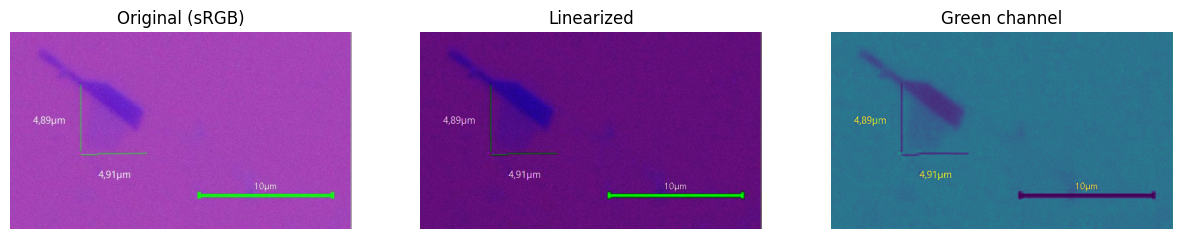

In [34]:
img_original, img_linear = get_uploaded_image(uploader)
green_channel = img_linear[:, :, 0]  # index 1 = Green (0=Red, 1=Green, 2=Blue)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img_original)
plt.title("Original (sRGB)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.clip(img_linear, 0, 1))
plt.title("Linearized")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(green_channel)
plt.title("Green channel")
plt.axis("off")
plt.show()

In [7]:
def denoise_image(img_gray):
    """
    Apply denoising to grayscale image.
    
    Parameters
    ----------
    img_gray : np.ndarray
        Input grayscale image in [0,1].
    method : str
        Denoising method: "bilateral".
        
    Returns
    -------
    np.ndarray
        Denoised grayscale image.
    """
    # OpenCV bilateral filter (fast, good for edges)
    denoised = cv2.bilateralFilter((img_gray*255).astype("uint8"), 
                                       d=9, sigmaColor=75, sigmaSpace=75)
    denoised = denoised.astype("float32") / 255.0
    return denoised    

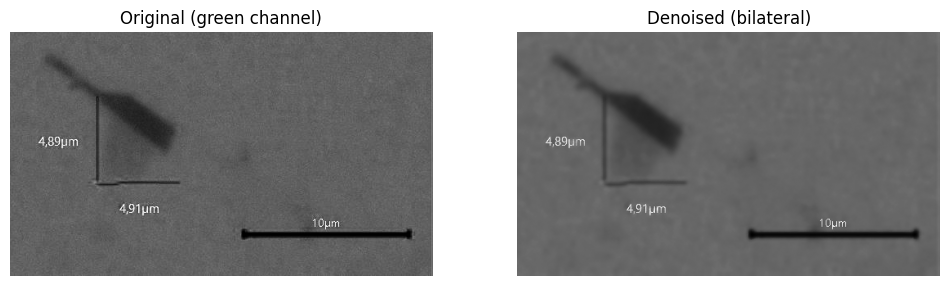

In [43]:
green_denoised = denoise_image(green_channel)

# Show before and after
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(green_channel, cmap="gray")
plt.title("Original (green channel)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(green_denoised, cmap="gray")
plt.title("Denoised (bilateral)")
plt.axis("off")

plt.show()

In [45]:
def select_roi(img_gray):
    """
    Allow user to select a rectangular ROI from an image.
    
    Parameters
    ----------
    img_gray : np.ndarray
        Input grayscale image.
        
    Returns
    -------
    np.ndarray
        Cropped ROI image.
    """
    # Convert to uint8 for OpenCV display
    img_uint8 = (img_gray * 255).astype("uint8")
    
    # Open interactive ROI selection window
    r = cv2.selectROI("Select ROI", img_uint8, showCrosshair=True)
    cv2.destroyAllWindows()
    
    x, y, w, h = r
    roi = img_gray[y:y+h, x:x+w]
    return roi


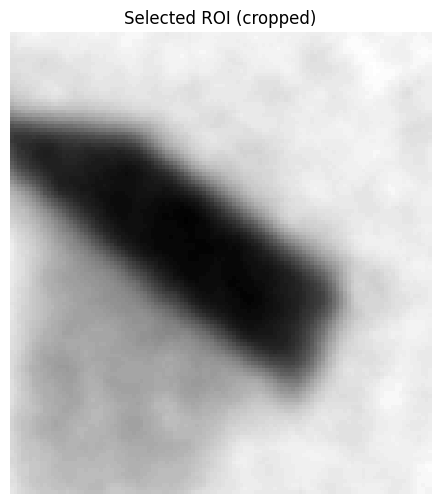

In [46]:
# Let user select ROI
roi_img = select_roi(green_denoised)

# Show result
plt.figure(figsize=(8,6))
plt.imshow(roi_img, cmap="gray")
plt.title("Selected ROI (cropped)")
plt.axis("off")
plt.show()


In [9]:
def segment_multi_otsu(img_gray, n_classes=3):
    """
    Segment image using multi-Otsu thresholding.

    Parameters
    ----------
    img_gray : np.ndarray
        Input grayscale image (float32, range [0,1]).
    n_classes : int
        Number of classes (default=3: background + 2 levels of flakes).

    Returns
    -------
    np.ndarray
        Labeled image with values {0,1,...,n_classes-1}.
    np.ndarray
        Threshold values found by multi-Otsu.
    """
    thresholds = threshold_multiotsu(img_gray, classes=n_classes)
    segmented = np.digitize(img_gray, bins=thresholds)
    return segmented, thresholds

Thresholds found: [0.2390625  0.33697915]


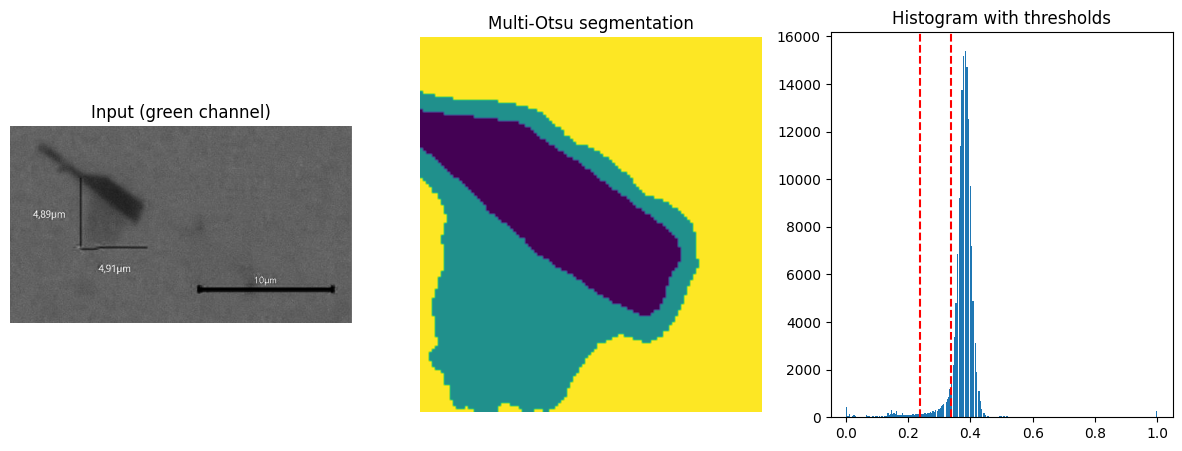

In [50]:
n_classes = 3
segmented, thresholds = segment_multi_otsu(roi_img, n_classes=n_classes)

print("Thresholds found:", thresholds)

# Show results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(green_channel, cmap="gray")
plt.title("Input (green channel)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(segmented, cmap="viridis")
plt.title("Multi-Otsu segmentation")
plt.axis("off")

plt.subplot(1,3,3)
plt.hist(green_channel.ravel(), bins=256)
for t in thresholds:
    plt.axvline(t, color="red", linestyle="--")
plt.title("Histogram with thresholds")
plt.show()

In [80]:
from skimage import measure

def analyze_and_plot_regions(segmented, img_gray, min_size=50):
    """
    Analyze flakes from multi-Otsu segmentation and overlay results
    on the original grayscale ROI.
    """
    results = []

    # Detect background = most frequent class
    unique, counts = np.unique(segmented, return_counts=True)
    background_class = unique[np.argmax(counts)]
    bg_mask = (segmented == background_class)
    background_intensity = img_gray[bg_mask].mean()

    flake_id = 1
    for label in unique:
        if label == background_class:
            continue

        mask = (segmented == label)
        labeled = measure.label(mask)

        for region in measure.regionprops(labeled, intensity_image=img_gray):
            if region.area < min_size:
                continue

            region_intensity = region.mean_intensity
            contrast = (background_intensity - region_intensity) / background_intensity * 100

            # Estimate number of layers
            if 4 <= contrast <= 8:
                layers = "1 layer"
            elif 8 < contrast <= 11:
                layers = "2 layers"
            elif 11 < contrast <= 15:
                layers = "3 layers"
            elif contrast > 15:
                layers = "4+ layers"
            else:
                layers = "uncertain"

            results.append({
                "flake_id": flake_id,
                "area_px": int(region.area),
                "mean_intensity": float(region_intensity),
                "contrast_%": float(contrast),
                "estimated_layers": layers
            })

            flake_id += 1

    # Convert to DataFrame
    df = pd.DataFrame(results)

    # ---- Plot on original ROI ----
    plt.figure(figsize=(6,6))
    plt.imshow(img_gray, cmap="gray")
    plt.title("ROI with estimated graphene layers")

    for r in results:
        # Find centroid of this flake
        mask = (segmented != background_class) & (segmented == unique[results.index(r)])
        # safer: compute centroid from regionprops again
        labeled = measure.label(segmented == unique[results.index(r)])
        region = [reg for reg in measure.regionprops(labeled) if reg.area >= min_size][0]
        y, x = region.centroid
        plt.text(x, y, r["estimated_layers"], color="red",
                 ha="center", va="center", fontsize=9,
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    plt.axis("off")
    plt.show()

    return df



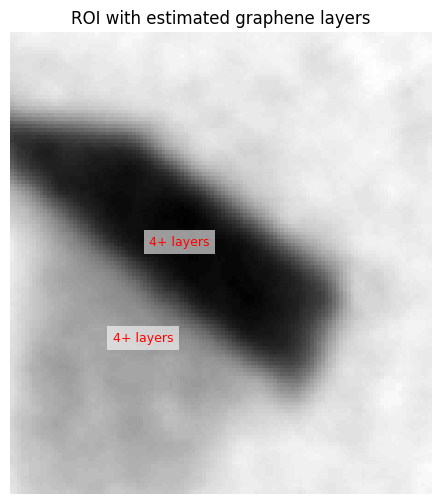

,flake_id,area_px,mean_intensity,contrast_%,estimated_layers
0,1,2711,0.172792,53.595852,4+ layers
1,2,4020,0.302682,18.713346,4+ layers


In [82]:
# Run the analysis
results = analyze_and_plot_regions(segmented, roi_img)
from IPython.display import display
display(results)
